# AI Job Replacement Data Analysis

## Import libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

## Data cleaning

In [2]:
# Data has been extracted from "https://www.kaggle.com/datasets/dmahajanbe23/ai-job-replacement-and-skill-shift-dataset/data"

df = pd.read_csv('../data/ai_job_replacement_2020_2026_v2.csv')

In [3]:
df.head()

,job_id,job_role,industry,country,year,automation_risk_percent,ai_replacement_score,skill_gap_index,salary_before_usd,salary_after_usd,salary_change_percent,skill_demand_growth_percent,remote_feasibility_score,ai_adoption_level,education_requirement_level,automation_risk_category,skill_transition_pressure,wage_volatility_index,reskilling_urgency_score,ai_disruption_intensity
0,0,Data Analyst,Technology,Canada,2021,26.22,30.94,73.20,101839.02,99454.42,-2.34,2.66,15.23,86.62,2,Low,49.710,2.34,33.150,22.711764
1,1,Accountant,Finance,Brazil,2020,52.08,56.41,2.06,146389.18,139516.59,-4.69,10.43,26.36,18.34,5,Medium,27.070,4.69,22.857,9.551472
2,2,Teacher,Technology,USA,2020,31.30,31.61,43.19,64947.50,58369.41,-10.13,8.14,36.29,36.64,2,Medium,37.245,10.13,28.516,11.468320
3,3,Customer Support Rep,Technology,Brazil,2021,56.92,63.42,19.97,91708.13,86715.70,-5.44,6.11,64.68,17.05,5,Medium,38.445,5.44,30.391,9.704860
4,4,Teacher,Manufacturing,Japan,2024,14.55,17.17,96.56,127007.68,119379.11,-6.01,2.08,71.58,44.02,3,Low,55.555,6.01,36.591,6.404910


In [4]:
df = df.drop(columns=['job_id'])

In [5]:
print('Any duplicates: ', df.duplicated().any())

Any duplicates:  False


In [6]:
df.head()

,job_role,industry,country,year,automation_risk_percent,ai_replacement_score,skill_gap_index,salary_before_usd,salary_after_usd,salary_change_percent,skill_demand_growth_percent,remote_feasibility_score,ai_adoption_level,education_requirement_level,automation_risk_category,skill_transition_pressure,wage_volatility_index,reskilling_urgency_score,ai_disruption_intensity
0,Data Analyst,Technology,Canada,2021,26.22,30.94,73.20,101839.02,99454.42,-2.34,2.66,15.23,86.62,2,Low,49.710,2.34,33.150,22.711764
1,Accountant,Finance,Brazil,2020,52.08,56.41,2.06,146389.18,139516.59,-4.69,10.43,26.36,18.34,5,Medium,27.070,4.69,22.857,9.551472
2,Teacher,Technology,USA,2020,31.30,31.61,43.19,64947.50,58369.41,-10.13,8.14,36.29,36.64,2,Medium,37.245,10.13,28.516,11.468320
3,Customer Support Rep,Technology,Brazil,2021,56.92,63.42,19.97,91708.13,86715.70,-5.44,6.11,64.68,17.05,5,Medium,38.445,5.44,30.391,9.704860
4,Teacher,Manufacturing,Japan,2024,14.55,17.17,96.56,127007.68,119379.11,-6.01,2.08,71.58,44.02,3,Low,55.555,6.01,36.591,6.404910


In [7]:
missing_values = df.isna().sum()

print('Missing values: ')
print(missing_values)

Missing values: 
job_role                       0
industry                       0
country                        0
year                           0
automation_risk_percent        0
ai_replacement_score           0
skill_gap_index                0
salary_before_usd              0
salary_after_usd               0
salary_change_percent          0
skill_demand_growth_percent    0
remote_feasibility_score       0
ai_adoption_level              0
education_requirement_level    0
automation_risk_category       0
skill_transition_pressure      0
wage_volatility_index          0
reskilling_urgency_score       0
ai_disruption_intensity        0
dtype: int64


In [8]:
# No need to check outliers

In [9]:
df.dtypes

job_role                        object
industry                        object
country                         object
year                             int64
automation_risk_percent        float64
ai_replacement_score           float64
skill_gap_index                float64
salary_before_usd              float64
salary_after_usd               float64
salary_change_percent          float64
skill_demand_growth_percent    float64
remote_feasibility_score       float64
ai_adoption_level              float64
education_requirement_level      int64
automation_risk_category        object
skill_transition_pressure      float64
wage_volatility_index          float64
reskilling_urgency_score       float64
ai_disruption_intensity        float64
dtype: object

In [10]:
print('Dataset shape: {} rows, {} columns'.format(df.shape[0], df.shape[1]))

Dataset shape: 15000 rows, 19 columns


In [11]:
# Key columns explanation:

# automation_risk_percent is the estimated probability that the job could be replaced by AI.
# The higher, the higher the risk

# ai_replacement_score is a normalized score, estimating how likely AI could replace this role.
# This could include factors such as task automation, AI adoption, and skillset

# skill_gap_index measures the difference between current worker skills and the skills required in an AI-driven environment.
# Higher value indicate a significant skill mismatch

# skill_demand_growth_percent refers to the demand for skills associated with this job.
# Higher percent indicates big growth

# skill_transition_pressure indicates how strongly workers in this job must shift to new skills due to AI changes
# Higher value means more pressure to transition

# reskilling_urgency_score is about how urgently workers need to learn new skills to stay employable.
# Higher value means it's more urgent

# remote_feasibility_score measures how easily the job can be performed remotely
# Higher value means it's more feasible

# ai_adoption_level is the degree to which AI is adopted in that job, a maturity index level taking into account industry and country
# Higher value means more mature

# ai_disruption_intensity measures how strongly AI is disrupting the role, considering automation risk, skills changes, wage impact, and AI adoption
# Higher value means more disruption

# education_requirement_level encodes the level of education required for the role.
# 1 means high school, 5 means PhD

# wage_volatility_index indicates how unstable wages are for that role due to technological changes.
# Higher value means salaries fluctuate more and job market uncertainty is higher

In [12]:
print(df.describe())

               year  automation_risk_percent  ai_replacement_score  \
count  15000.000000             15000.000000          15000.000000   
mean    2022.997200                46.176347             46.155907   
std        1.999365                21.663635             22.351347   
min     2020.000000                 5.000000              4.010000   
25%     2021.000000                28.790000             28.357500   
50%     2023.000000                46.235000             45.675000   
75%     2025.000000                63.602500             62.712500   
max     2026.000000                94.980000            113.070000   

       skill_gap_index  salary_before_usd  salary_after_usd  \
count     15000.000000       15000.000000      15000.000000   
mean         50.003708       89771.375196      89870.633937   
std          28.811040       34522.125434      35897.592992   
min           0.000000       30003.690000      19022.670000   
25%          25.170000       60127.225000      59223.4

In [13]:
df['job_role'].unique()

array(['Data Analyst', 'Accountant', 'Teacher', 'Customer Support Rep',
       'Software Engineer', 'Marketing Specialist', 'Financial Analyst',
       'HR Manager', 'Mechanical Engineer', 'Truck Driver'], dtype=object)

In [14]:
sorted(df['year'].unique())

[2020, 2021, 2022, 2023, 2024, 2025, 2026]

In [15]:
values = {
    1: 'High school',
    2: 'Diploma',
    3: 'Bachelor\'s',
    4: 'Master\'s',
    5: 'PhD'
}

df['education_requirement_level'] = df['education_requirement_level'].map(values)

## Data exploration

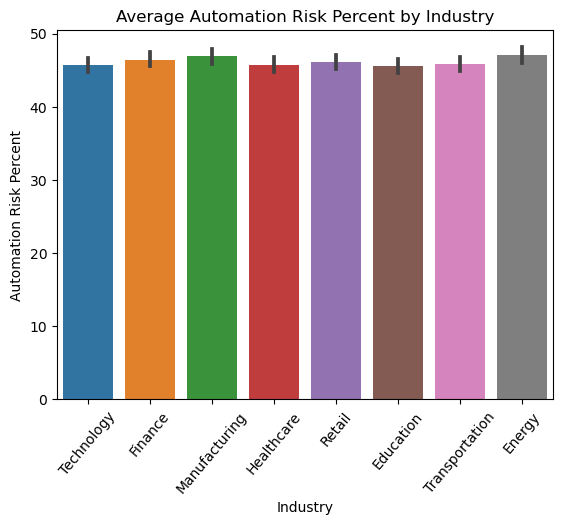

In [16]:
sns.barplot(x='industry', y='automation_risk_percent', data=df)

plt.title('Average Automation Risk Percent by Industry')
plt.xlabel('Industry')
plt.ylabel('Automation Risk Percent')
plt.xticks(rotation=50)
plt.show()

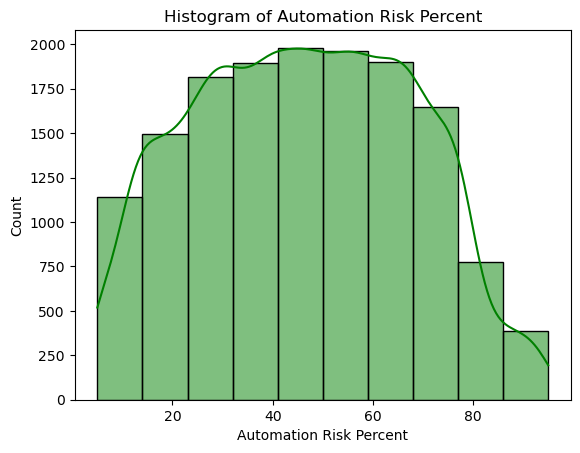

In [17]:
sns.histplot(x='automation_risk_percent', data=df, kde=True, color='green', bins=10)
plt.title('Histogram of Automation Risk Percent')
plt.xlabel('Automation Risk Percent')
plt.show()

<Axes: xlabel='ai_adoption_level', ylabel='automation_risk_percent'>

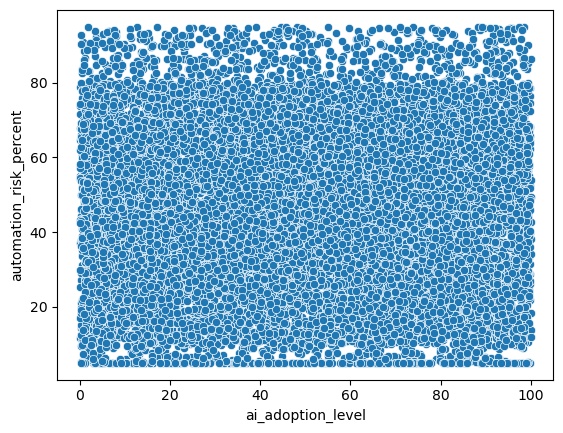

In [18]:
sns.scatterplot(x='ai_adoption_level', y='automation_risk_percent', data=df)

In [19]:
# Each industries are evenly matched with the average automation risk percent
# The scatterplot does not show any clear correlation with AI adoption level

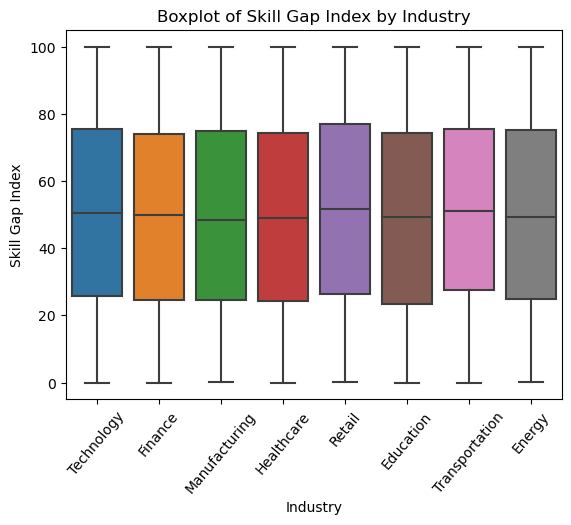

In [20]:
sns.boxplot(x='industry', y='skill_gap_index', data=df)
plt.title('Boxplot of Skill Gap Index by Industry')
plt.xlabel('Industry')
plt.ylabel('Skill Gap Index')
plt.xticks(rotation=50)
plt.show()

In [21]:
df.groupby('industry')['automation_risk_percent'].mean()

industry
Education         45.595535
Energy            47.020782
Finance           46.407925
Healthcare        45.760880
Manufacturing     46.876564
Retail            46.129989
Technology        45.746993
Transportation    45.872329
Name: automation_risk_percent, dtype: float64

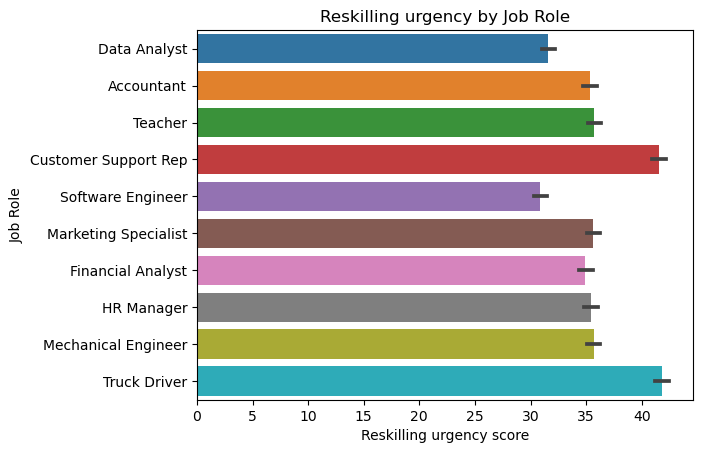

In [22]:
sns.barplot(x='reskilling_urgency_score', y='job_role', data=df)
plt.title('Reskilling urgency by Job Role')
plt.xlabel('Reskilling urgency score')
plt.ylabel('Job Role')
plt.show()

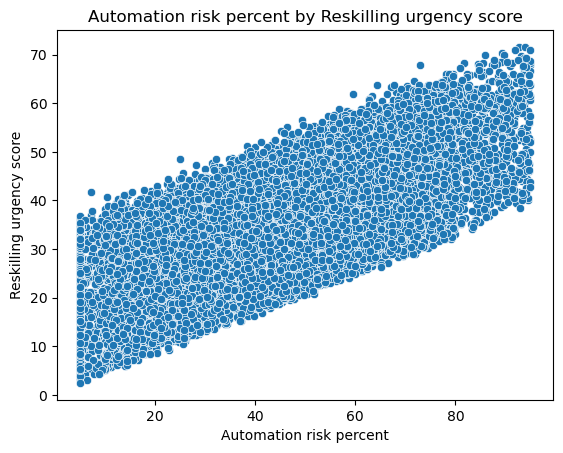

In [23]:
sns.scatterplot(x='automation_risk_percent', y='reskilling_urgency_score', data=df)
plt.title('Automation risk percent by Reskilling urgency score')
plt.xlabel('Automation risk percent')
plt.ylabel('Reskilling urgency score')
plt.show()

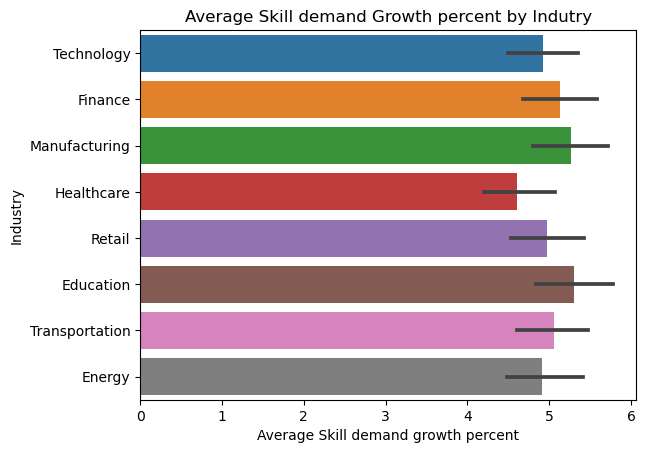

In [24]:
sns.barplot(x='skill_demand_growth_percent', y='industry', data=df)
plt.title('Average Skill demand Growth percent by Indutry')
plt.xlabel('Average Skill demand growth percent')
plt.ylabel('Industry')
plt.show()

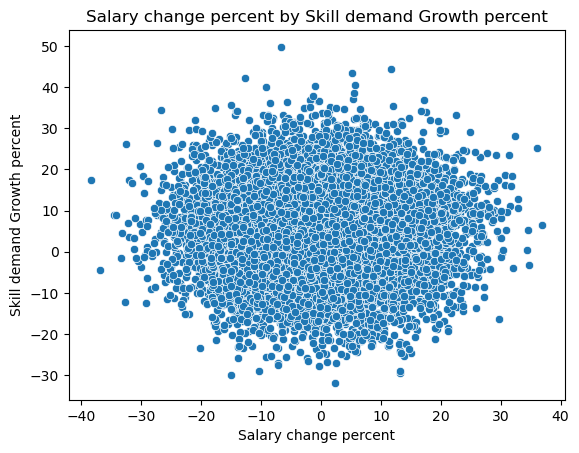

In [25]:
sns.scatterplot(x='salary_change_percent', y='skill_demand_growth_percent', data=df)
plt.title('Salary change percent by Skill demand Growth percent')
plt.xlabel('Salary change percent')
plt.ylabel('Skill demand Growth percent')
plt.show()

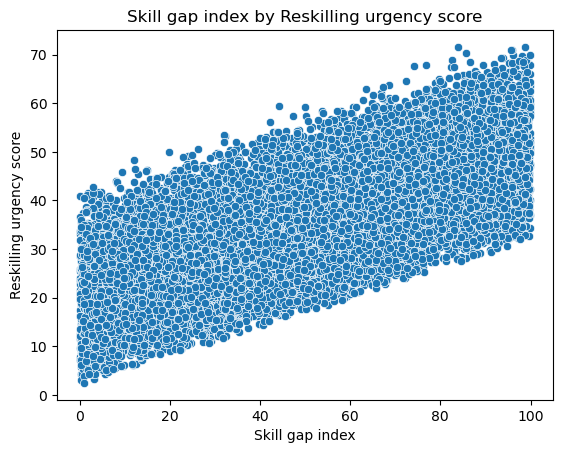

In [26]:
sns.scatterplot(x='skill_gap_index', y='reskilling_urgency_score', data=df)
plt.title('Skill gap index by Reskilling urgency score')
plt.xlabel('Skill gap index')
plt.ylabel('Reskilling urgency score')
plt.show()

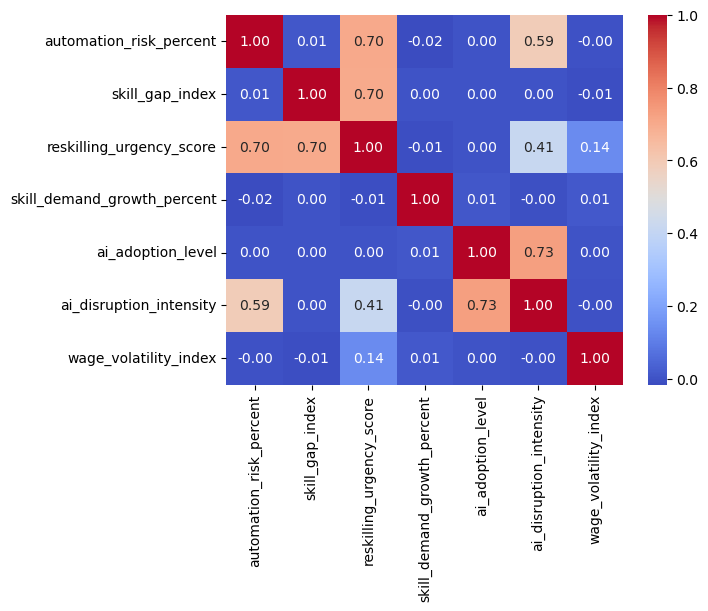

In [27]:
num_cols = ['automation_risk_percent', 'skill_gap_index', 
            'reskilling_urgency_score','skill_demand_growth_percent', 
            'ai_adoption_level', 'ai_disruption_intensity', 
            'wage_volatility_index']

sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.show()

In [28]:
df[['ai_disruption_intensity', 'skill_transition_pressure']].corr()

,ai_disruption_intensity,skill_transition_pressure
ai_disruption_intensity,1.000000,0.355704
skill_transition_pressure,0.355704,1.000000


In [29]:
df[['automation_risk_percent', 'salary_change_percent']].corr()

,automation_risk_percent,salary_change_percent
automation_risk_percent,1.000000,-0.005281
salary_change_percent,-0.005281,1.000000


In [30]:
df[['remote_feasibility_score', 'automation_risk_percent']].corr()

,remote_feasibility_score,automation_risk_percent
remote_feasibility_score,1.000000,0.001511
automation_risk_percent,0.001511,1.000000


In [31]:
df['automation_risk_percent'].describe()

count    15000.000000
mean        46.176347
std         21.663635
min          5.000000
25%         28.790000
50%         46.235000
75%         63.602500
max         94.980000
Name: automation_risk_percent, dtype: float64

In [32]:
df['skill_gap_index'].describe()

count    15000.000000
mean        50.003708
std         28.811040
min          0.000000
25%         25.170000
50%         49.930000
75%         75.025000
max         99.980000
Name: skill_gap_index, dtype: float64

In [33]:
df['reskilling_urgency_score'].describe()

count    15000.000000
mean        35.867584
std         12.416415
min          2.456000
25%         26.982250
50%         35.871000
75%         44.698500
max         71.579000
Name: reskilling_urgency_score, dtype: float64

In [34]:
df['skill_demand_growth_percent'].describe()

count    15000.000000
mean         5.020461
std          9.956155
min        -31.880000
25%         -1.662500
50%          4.960000
75%         11.730000
max         49.790000
Name: skill_demand_growth_percent, dtype: float64

<Axes: xlabel='skill_gap_index', ylabel='Count'>

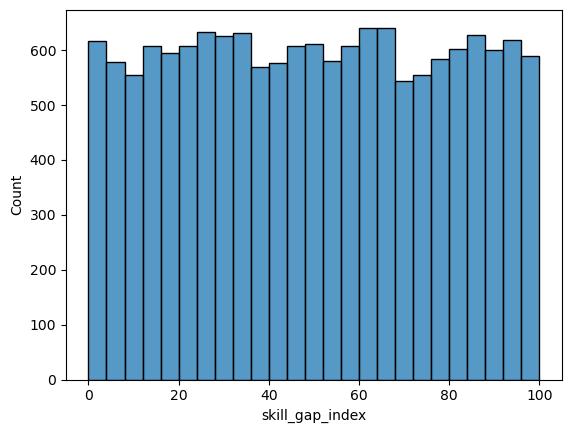

In [35]:
sns.histplot(x='skill_gap_index', data=df)

<Axes: xlabel='reskilling_urgency_score', ylabel='Count'>

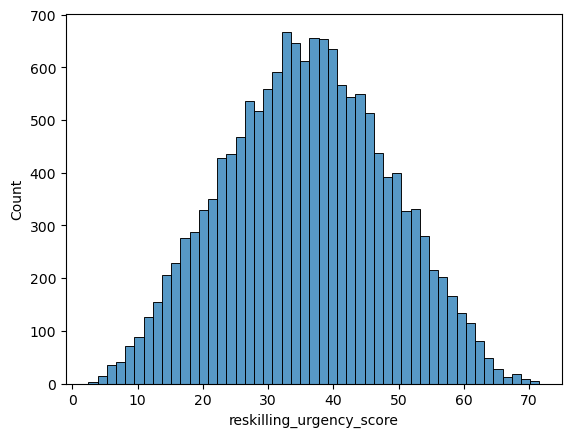

In [36]:
sns.histplot(x='reskilling_urgency_score', data=df)

<Axes: xlabel='wage_volatility_index'>

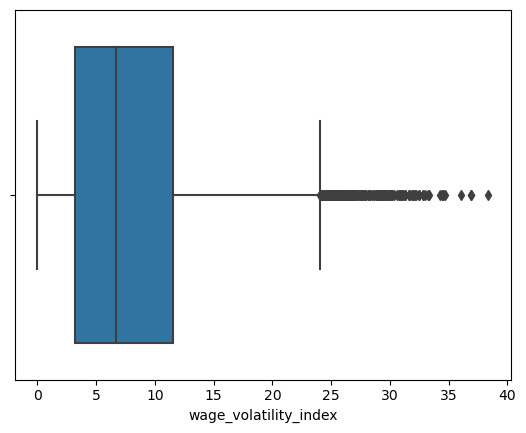

In [37]:
sns.boxplot(x='wage_volatility_index', data=df)

In [38]:
# Some roles have higher wage volatility index, indicating that those outliers
# may need urgent reskilling

<Axes: xlabel='year', ylabel='automation_risk_percent'>

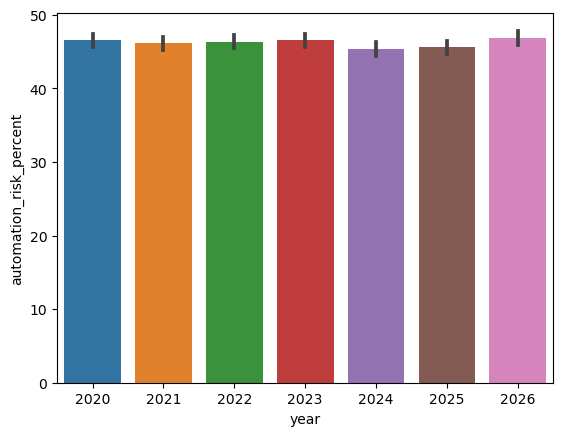

In [39]:
sns.barplot(x='year', y='automation_risk_percent', data=df)

## Model training

### Discover features that are significant for reskilling

In [40]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

X = df.drop(['reskilling_urgency_score', 'job_role', 'industry', 'country'], axis=1)
y = df['reskilling_urgency_score']

cat_cols = X.select_dtypes(include=['object']).columns.tolist()
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols)
])

In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [42]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor

model = Pipeline([
    ('prep', preprocessor),
    ('reg', RandomForestRegressor(
        n_estimators=300,
        max_depth=10,
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=42))
])

model.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['year',
                                                   'automation_risk_percent',
                                                   'ai_replacement_score',
                                                   'skill_gap_index',
                                                   'salary_before_usd',
                                                   'salary_after_usd',
                                                   'salary_change_percent',
                                                   'skill_demand_growth_percent',
                                                   'remote_feasibility_score',
                                                   'ai_adoption_level',
                                                   'skill_transition_pressure',
                                                   'wage_volatility_index',
                                                   'ai_disruption_intensity']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['education_requirement_level',
                                                   'automation_risk_category'])])),
                ('reg',
                 RandomForestRegressor(max_depth=10, min_samples_leaf=5,
                                       min_samples_split=10, n_estimators=300,
                                       random_state=42))])

In [43]:
# 'model' here is a pipeline
importance = model.named_steps['reg'].feature_importances_

preprocessor = model.named_steps['prep']

num_features = num_cols
cat_features = preprocessor.named_transformers_['cat'].get_feature_names_out(cat_cols)
all_features = list(num_features) + list(cat_features)

feat_imp = pd.DataFrame({
    'feature': all_features,
    'importance': importance
}).sort_values(by='importance', ascending=False)

feat_imp.head()

,feature,importance
10,skill_transition_pressure,0.961684
11,wage_volatility_index,0.019484
1,automation_risk_percent,0.016853
2,ai_replacement_score,0.001547
3,skill_gap_index,0.000162


In [44]:
# Skill transition is the most significant feature

### Discover features that are significant for automation risk

In [45]:
X = df.drop(['automation_risk_percent', 'automation_risk_category', 'job_role', 'industry', 'country'], axis=1)
y = df['automation_risk_percent']

cat_cols = X.select_dtypes(include=['object']).columns.tolist()
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols)
])

In [46]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [47]:
model = Pipeline([
    ('prep', preprocessor),
    ('reg', RandomForestRegressor(
        n_estimators=300,
        max_depth=10,
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=42))
])

model.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['year',
                                                   'ai_replacement_score',
                                                   'skill_gap_index',
                                                   'salary_before_usd',
                                                   'salary_after_usd',
                                                   'salary_change_percent',
                                                   'skill_demand_growth_percent',
                                                   'remote_feasibility_score',
                                                   'ai_adoption_level',
                                                   'skill_transition_pressure',
                                                   'wage_volatility_index',
                                                   'reskilling_urgency_score',
                                                   'ai_disruption_intensity']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['education_requirement_level'])])),
                ('reg',
                 RandomForestRegressor(max_depth=10, min_samples_leaf=5,
                                       min_samples_split=10, n_estimators=300,
                                       random_state=42))])

In [48]:
importance = model.named_steps['reg'].feature_importances_

preprocessor = model.named_steps['prep']

num_features = num_cols
cat_features = preprocessor.named_transformers_['cat'].get_feature_names_out(cat_cols)
all_features = list(num_features) + list(cat_features)

feat_imp = pd.DataFrame({
    'feature': all_features,
    'importance': importance
}).sort_values(by='importance', ascending=False)

feat_imp.head()

,feature,importance
1,ai_replacement_score,0.964667
11,reskilling_urgency_score,0.010643
2,skill_gap_index,0.008416
12,ai_disruption_intensity,0.007815
9,skill_transition_pressure,0.003853


### Discover which features are significant for salary change

In [49]:
X = df.drop(['salary_change_percent', 'job_role', 'industry', 'country'], axis=1)
y = df['salary_change_percent']

cat_cols = X.select_dtypes(include=['object']).columns.tolist()
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols)
])

In [50]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [51]:
model = Pipeline([
    ('prep', preprocessor),
    ('reg', RandomForestRegressor(
        n_estimators=300,
        max_depth=10,
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=42))
])

model.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['year',
                                                   'automation_risk_percent',
                                                   'ai_replacement_score',
                                                   'skill_gap_index',
                                                   'salary_before_usd',
                                                   'salary_after_usd',
                                                   'skill_demand_growth_percent',
                                                   'remote_feasibility_score',
                                                   'ai_adoption_level',
                                                   'skill_transition_pressure',
                                                   'wage_volatility_index',
                                                   'reskilling_urgency_score',
                                                   'ai_disruption_intensity']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['education_requirement_level',
                                                   'automation_risk_category'])])),
                ('reg',
                 RandomForestRegressor(max_depth=10, min_samples_leaf=5,
                                       min_samples_split=10, n_estimators=300,
                                       random_state=42))])

In [52]:
importance = model.named_steps['reg'].feature_importances_

preprocessor = model.named_steps['prep']

num_features = num_cols
cat_features = preprocessor.named_transformers_['cat'].get_feature_names_out(cat_cols)
all_features = list(num_features) + list(cat_features)

feat_imp = pd.DataFrame({
    'feature': all_features,
    'importance': importance
}).sort_values(by='importance', ascending=False)

feat_imp.head()

,feature,importance
10,wage_volatility_index,0.405893
5,salary_after_usd,0.344378
4,salary_before_usd,0.249607
8,ai_adoption_level,0.000023
7,remote_feasibility_score,0.000020


### Key questions' research

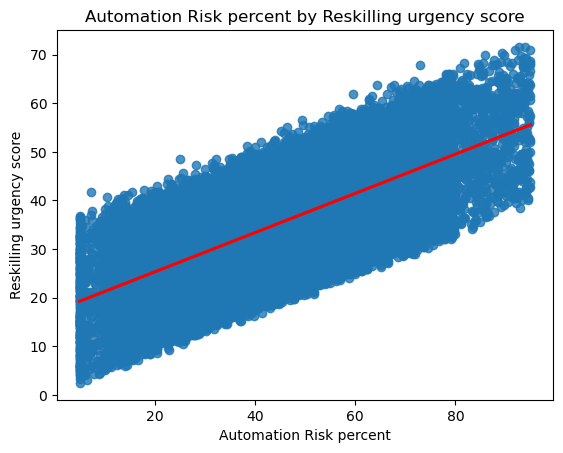

In [53]:
sns.regplot(x='automation_risk_percent', y='reskilling_urgency_score', data=df, line_kws={'color': 'red'})

plt.title('Automation Risk percent by Reskilling urgency score')
plt.xlabel('Automation Risk percent')
plt.ylabel('Reskilling urgency score')
plt.show()

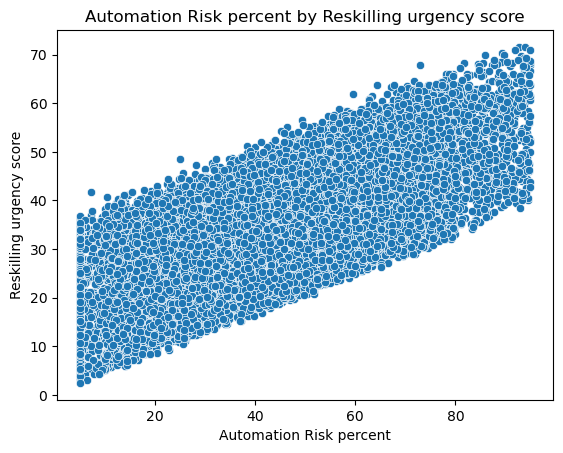

In [54]:
sns.scatterplot(x='automation_risk_percent', y='reskilling_urgency_score', data=df)

plt.title('Automation Risk percent by Reskilling urgency score')
plt.xlabel('Automation Risk percent')
plt.ylabel('Reskilling urgency score')
plt.show()

In [55]:
df[['automation_risk_percent', 'reskilling_urgency_score']].corr()

,automation_risk_percent,reskilling_urgency_score
automation_risk_percent,1.000000,0.704172
reskilling_urgency_score,0.704172,1.000000


In [56]:
df.groupby('job_role')[['automation_risk_percent', 'reskilling_urgency_score']].mean().sort_values(by='automation_risk_percent', ascending=False)

,automation_risk_percent,reskilling_urgency_score
job_role,,
Truck Driver,60.740895,41.810564
Customer Support Rep,59.851052,41.595427
Marketing Specialist,45.438711,35.663488
Mechanical Engineer,45.397903,35.670092
Teacher,45.137897,35.722418
HR Manager,45.091339,35.443909
Accountant,44.979548,35.317330
Financial Analyst,44.704972,34.929181
Data Analyst,35.455807,31.608221


In [57]:
df.groupby('job_role')[['ai_adoption_level', 'ai_disruption_intensity']].mean().sort_values(by='ai_disruption_intensity', ascending=False)

,ai_adoption_level,ai_disruption_intensity
job_role,,
Truck Driver,49.007047,29.718229
Customer Support Rep,49.039544,29.471336
HR Manager,50.915889,22.986383
Accountant,50.913915,22.970306
Financial Analyst,50.867431,22.968668
Mechanical Engineer,50.503925,22.787930
Teacher,49.615245,22.495273
Marketing Specialist,48.914926,22.173436
Software Engineer,49.596660,17.339496


In [58]:
rank = df.groupby('job_role')[['ai_adoption_level', 'ai_disruption_intensity']].mean().sort_values(by='ai_disruption_intensity', ascending=False)

top5 = rank.head(5).round(2)
top5['rank'] = range(1, 6)

top5 = top5.reset_index()[['rank', 'job_role', 'ai_adoption_level', 'ai_disruption_intensity']]

In [59]:
top5

,rank,job_role,ai_adoption_level,ai_disruption_intensity
0,1,Truck Driver,49.01,29.72
1,2,Customer Support Rep,49.04,29.47
2,3,HR Manager,50.92,22.99
3,4,Accountant,50.91,22.97
4,5,Financial Analyst,50.87,22.97


### ANOVA testing
Null hypothesis: All group means are equal in ai_replacement_score

Alternate hypothesis: At least one group mean is different

In [60]:
df['risk_group'] = pd.qcut(df['ai_replacement_score'], q=3, labels=['Low', 'Medium', 'High'])

In [61]:
from scipy.stats import f_oneway

groups = [group['reskilling_urgency_score'].values for name, group in df.groupby('risk_group')]

f_stat, p_val = f_oneway(*groups)

print(f"F = {f_stat}, p-value = {p_val}")

F = 5011.402392848998, p-value = 0.0


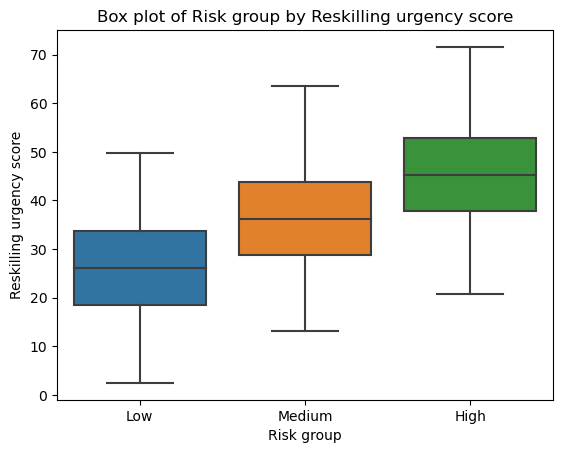

In [62]:
sns.boxplot(x='risk_group', y='reskilling_urgency_score', data=df)

plt.title('Box plot of Risk group by Reskilling urgency score')
plt.xlabel('Risk group')
plt.ylabel('Reskilling urgency score')
plt.show()

In [63]:
# P-value is lower than 0.05, and therefore there is statistically significant
# difference in reskilling urgency score across risk groups

### Post-hoc test (Tukey test)

In [64]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey = pairwise_tukeyhsd(
    endog=df['reskilling_urgency_score'],
    groups=df['risk_group'],
    alpha=0.05
)

print(tukey)

 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj  lower    upper   reject
-----------------------------------------------------
  High    Low -19.2422   0.0 -19.6929 -18.7915   True
  High Medium  -9.1198   0.0  -9.5704  -8.6691   True
   Low Medium  10.1225   0.0   9.6718  10.5731   True
-----------------------------------------------------


In [65]:
# Results show:
# High vs Low (Low-High) -> -19.24, which means High group has much higher 
# reskilling urgency than Low by 19 points difference

# High vs Medium -> -9.12, which means moderate difference

# Low vs Medium -> +10.11, which means Medium group has 10 points higher 
# urgency than Low

# There is a clear positive relationship between ai_replacement_score and
# reskilling urgency.
# This means employees recognize risk and they respond by wanting to reskill.

In [66]:
df.groupby('risk_group')['reskilling_urgency_score'].mean()

risk_group
Low       26.080570
Medium    36.203026
High      45.322802
Name: reskilling_urgency_score, dtype: float64

In [67]:
df.groupby('risk_group')['ai_replacement_score'].mean()

risk_group
Low       21.197406
Medium    45.694474
High      71.586198
Name: ai_replacement_score, dtype: float64

### ANOVA testing

Null hypothesis: All group means are equal in skill_gap_index

Alternate hypothesis: At least one group mean is different

In [68]:
df['skill_gap_group'] = pd.qcut(df['skill_gap_index'], q=3, labels=['Low', 'Medium', 'High'])

In [69]:
groups = [group['reskilling_urgency_score'].values for name, group in df.groupby('skill_gap_group')]

f_stat, p_val = f_oneway(*groups)

print(f"F = {f_stat}, p-value = {p_val}")

F = 5878.066682779579, p-value = 0.0


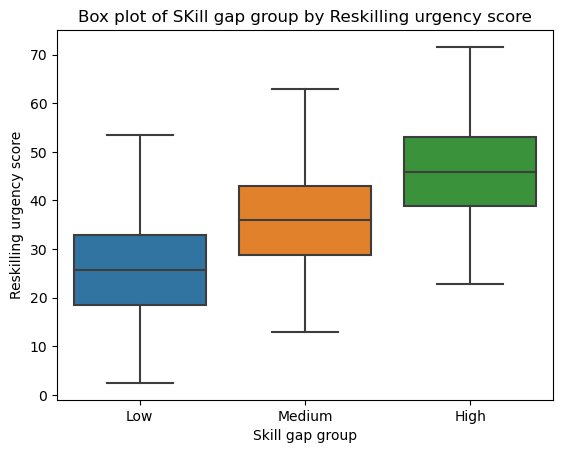

In [70]:
sns.boxplot(x='skill_gap_group', y='reskilling_urgency_score', data=df)

plt.title('Box plot of SKill gap group by Reskilling urgency score')
plt.xlabel('Skill gap group')
plt.ylabel('Reskilling urgency score')
plt.show()

In [71]:
# P-value is lower than 0.05, and therefore there is statistically significant
# difference in reskilling urgency score across skill gap indexes

In [72]:
tukey = pairwise_tukeyhsd(
    endog=df['reskilling_urgency_score'],
    groups=df['skill_gap_group'],
    alpha=0.05
)

print(tukey)

 Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj  lower    upper   reject
-----------------------------------------------------
  High    Low -20.1605   0.0 -20.5963 -19.7247   True
  High Medium -10.0477   0.0 -10.4836  -9.6119   True
   Low Medium  10.1128   0.0   9.6769  10.5486   True
-----------------------------------------------------


In [73]:
# Results show:
# High vs Low -> -20.16, which means employees with a higher skill gap index
# need reskilling more urgently

# High vs Medium -> -10.05, which is moderate

# Low vs Medium -> 10, which means that Medium group has 10 points higher skill
# gap than Low

# Reskilling urgency is driven by both perceived risk (external pressure) and
# capablity gaps (internal limitation)